# Machine Learning & AI

![Colegio Bourbaki](./Images/Bourbaki.png)

## Temporal Fusion Transformerr

Vamos a utilizar la libreria neuralforecst de la empresa NIXTLA de la cual importaremos el modelo TFT. También puede utilizarse la libreria pytorch forecasting. Ambas se apalancan PyTorch Lightning.

Links:

* **Pytorch Forecasting:** https://pytorch-forecasting.readthedocs.io/en/stable/index.html
* **Neural Forecast:** https://nixtlaverse.nixtla.io/neuralforecast/docs/getting-started/introduction.html
* **Pytorch Lightning:** https://lightning.ai/docs/pytorch/stable/

![Colegio Bourbaki](./Images/time_pred.png)

Fuente: https://arxiv.org/pdf/1912.09363

### Librerias

In [1]:
# Data Analysis
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Pytorch Lighting
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.tuner import Tuner

# Nixtla
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT
from neuralforecast.losses.pytorch import QuantileLoss, MQLoss
# from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
# from pytorch_forecasting.data import GroupNormalizer
# from pytorch_forecasting.metrics import  QuantileLoss, MAE, RMSE, SMAPE, MAPE, MASE
# from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# Utils
import pickle
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

No vamos a explicar nuevamente el contexto del problema, iremos directamente a la solución del problema ya planteado. La primera parte del código es similar, por lo tanto, muchas celdas no serán descriptas.

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
device

device(type='cuda')

Carga de Datos

In [4]:
x_train = pd.read_csv('./Data/SNCF/hard/Xtrain_hgcGIrA.csv')

In [5]:
index = x_train.index

In [6]:
index

RangeIndex(start=0, stop=31119, step=1)

In [7]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31119 entries, 0 to 31118
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         31119 non-null  object 
 1   train        31119 non-null  int64  
 2   way          31119 non-null  int64  
 3   station      31119 non-null  object 
 4   hour         27915 non-null  object 
 5   composition  31119 non-null  int64  
 6   p1q0         29067 non-null  float64
 7   p2q0         26974 non-null  float64
 8   p3q0         24935 non-null  float64
 9   p0q1         27917 non-null  float64
 10  p0q2         24720 non-null  float64
 11  p0q3         21527 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 2.8+ MB


In [8]:
df_x_train = x_train.copy(deep=True)

In [9]:
y_train = pd.read_csv(
    "/mnt/lg_externo/Pablo/Personal/Colegio_Bourbaki/ML_AI/Semana2/Data/SNCF/hard/Ytrain_yL5OjS4.csv"
)

In [10]:
y_train

,Unnamed: 0,p0q0
0,1,0.216
1,2,0.216
2,3,0.227
3,4,0.229
4,5,0.225
...,...,...
31114,31115,0.111
31115,31116,0.143
31116,31117,0.139
31117,31118,0.117


In [11]:
df_y_train = y_train[['p0q0']]
df_y_train = df_y_train.set_index(index, drop=True)

In [12]:
df_x_train

,date,train,way,station,hour,composition,p1q0,p2q0,p3q0,p0q1,p0q2,p0q3
0,2019-01-07,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.201,0.138,0.091
1,2019-01-08,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.204,0.152,0.106
2,2019-01-10,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.213,0.153,0.111
3,2019-01-11,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.213,0.152,0.108
4,2019-01-14,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.210,0.147,0.096
...,...,...,...,...,...,...,...,...,...,...,...,...
31114,2019-05-13,9,0,BE,08:00:00,2,0.152,0.18860,0.157000,0.080,0.100,NaN
31115,2019-05-14,9,0,BE,08:00:00,2,0.153,0.18040,0.191000,0.089,0.121,NaN
31116,2019-05-15,9,0,BE,08:00:00,2,0.166,0.14900,0.168000,0.099,0.129,NaN
31117,2019-03-21,9,0,BE,08:00:00,2,0.182,0.19300,0.162000,0.074,0.101,NaN


In [13]:
df_x_train['train'].unique()

array([ 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  2, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29,  3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,  4,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49,  5, 50, 51, 52, 53, 54, 55,
        6,  7,  8,  9])

In [14]:
df_x_train['train'].nunique()

55

In [15]:
df_x_train["station"].unique()

array(['AD', 'AI', 'AJ', 'AK', 'AM', 'AT', 'AW', 'AX', 'BB', 'BD', 'BE',
       'AE', 'AL', 'AO', 'AQ', 'BC', 'AB', 'AN', 'AS', 'BF', 'BG', 'BH',
       'AV', 'AF', 'AP', 'AZ', 'AA', 'AC', 'AG', 'AH', 'AR', 'AU', 'BA',
       'BI', 'BJ', 'AY'], dtype=object)

In [16]:
df_x_train["station"].nunique()

36

In [17]:
df_train = pd.concat(
    [
        df_x_train,
        df_y_train
    ],
    axis=1,
)

In [18]:
df_train

,date,train,way,station,hour,composition,p1q0,p2q0,p3q0,p0q1,p0q2,p0q3,p0q0
0,2019-01-07,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.201,0.138,0.091,0.216
1,2019-01-08,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.204,0.152,0.106,0.216
2,2019-01-10,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.213,0.153,0.111,0.227
3,2019-01-11,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.213,0.152,0.108,0.229
4,2019-01-14,1,0,AD,06:00:00,2,NaN,NaN,NaN,0.210,0.147,0.096,0.225
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31114,2019-05-13,9,0,BE,08:00:00,2,0.152,0.18860,0.157000,0.080,0.100,NaN,0.111
31115,2019-05-14,9,0,BE,08:00:00,2,0.153,0.18040,0.191000,0.089,0.121,NaN,0.143
31116,2019-05-15,9,0,BE,08:00:00,2,0.166,0.14900,0.168000,0.099,0.129,NaN,0.139
31117,2019-03-21,9,0,BE,08:00:00,2,0.182,0.19300,0.162000,0.074,0.101,NaN,0.117


In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31119 entries, 0 to 31118
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         31119 non-null  object 
 1   train        31119 non-null  int64  
 2   way          31119 non-null  int64  
 3   station      31119 non-null  object 
 4   hour         27915 non-null  object 
 5   composition  31119 non-null  int64  
 6   p1q0         29067 non-null  float64
 7   p2q0         26974 non-null  float64
 8   p3q0         24935 non-null  float64
 9   p0q1         27917 non-null  float64
 10  p0q2         24720 non-null  float64
 11  p0q3         21527 non-null  float64
 12  p0q0         31119 non-null  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 3.1+ MB


In [20]:
df_train.isna().sum()

date              0
train             0
way               0
station           0
hour           3204
composition       0
p1q0           2052
p2q0           4145
p3q0           6184
p0q1           3202
p0q2           6399
p0q3           9592
p0q0              0
dtype: int64

In [21]:
df_train['hour'].value_counts(dropna=False)

hour
07:00:00    10064
08:00:00    10028
06:00:00     4995
NaN          3204
09:00:00     2826
11:00:00        2
Name: count, dtype: int64

In [22]:
#Fill 'hour' nan valuee with -1
df_train['hour'] = df_train['hour'].fillna(-1)

In [23]:
df_train['hour'].value_counts(dropna=False)

hour
07:00:00    10064
08:00:00    10028
06:00:00     4995
-1           3204
09:00:00     2826
11:00:00        2
Name: count, dtype: int64

In [24]:
df_train['hour'] = df_train['hour'].apply(lambda x: '10:00:00' if x == -1 else x)

In [25]:
df_train['hour'].value_counts(dropna=False)

hour
07:00:00    10064
08:00:00    10028
06:00:00     4995
10:00:00     3204
09:00:00     2826
11:00:00        2
Name: count, dtype: int64

In [26]:
df_train["date"] = pd.to_datetime(df_train["date"], format="mixed")
df_train["hour"] = pd.to_datetime(df_train["hour"], format="%H:%M:%S").dt.hour

In [27]:
# Extract day of week and month as features
df_train['day_of_week'] = df_train['date'].dt.dayofweek
df_train['month'] = df_train['date'].dt.month

In [28]:
df_train['train'] = df_train['train'].astype("str")
df_train["station"] = df_train["station"].astype("str")
df_train["way"] = df_train["way"].astype("str")
df_train["composition"] = df_train["composition"].astype("str")
df_train = df_train.rename(columns={"train": "train_id"})

In [29]:
df_train.isna().sum()

date              0
train_id          0
way               0
station           0
hour              0
composition       0
p1q0           2052
p2q0           4145
p3q0           6184
p0q1           3202
p0q2           6399
p0q3           9592
p0q0              0
day_of_week       0
month             0
dtype: int64

In [30]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31119 entries, 0 to 31118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         31119 non-null  datetime64[ns]
 1   train_id     31119 non-null  object        
 2   way          31119 non-null  object        
 3   station      31119 non-null  object        
 4   hour         31119 non-null  int32         
 5   composition  31119 non-null  object        
 6   p1q0         29067 non-null  float64       
 7   p2q0         26974 non-null  float64       
 8   p3q0         24935 non-null  float64       
 9   p0q1         27917 non-null  float64       
 10  p0q2         24720 non-null  float64       
 11  p0q3         21527 non-null  float64       
 12  p0q0         31119 non-null  float64       
 13  day_of_week  31119 non-null  int32         
 14  month        31119 non-null  int32         
dtypes: datetime64[ns](1), float64(7), int32(3), object(4)

Vamos a crear una nueva columna llamada time_idx donde asignaremos cada fila en datos un índice basado en la posición de su valor de fecha (date) dentro de la variable de una lista (lista).

In [31]:
# First, sort the data by date and hour to ensure correct temporal ordering
df_train = df_train.sort_values(by=["date", "hour"]).reset_index(drop=True)

# Create a unique time index within each group of (train, station)
df_train["time_idx"] = df_train.groupby(["train_id", "station"]).cumcount()

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31119 entries, 0 to 31118
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         31119 non-null  datetime64[ns]
 1   train_id     31119 non-null  object        
 2   way          31119 non-null  object        
 3   station      31119 non-null  object        
 4   hour         31119 non-null  int32         
 5   composition  31119 non-null  object        
 6   p1q0         29067 non-null  float64       
 7   p2q0         26974 non-null  float64       
 8   p3q0         24935 non-null  float64       
 9   p0q1         27917 non-null  float64       
 10  p0q2         24720 non-null  float64       
 11  p0q3         21527 non-null  float64       
 12  p0q0         31119 non-null  float64       
 13  day_of_week  31119 non-null  int32         
 14  month        31119 non-null  int32         
 15  time_idx     31119 non-null  int64         
dtypes: d

El time_idx es un componente crucial a la hora de preparar datos para modelos de series temporales, especialmente en el contexto de la TFT. Sirve para varios propósitos importantes:

* Orden temporal: Proporciona un índice numérico secuencial que representa el orden de los pasos temporales en los datos.
* Alinear secuencias: Ayuda a alinear correctamente las secuencias para las partes codificadora (encoder) y decodificadora (decoder) del modelo.
* Manejo de múltiples series temporales: Cuando se manejan múltiples series temporales (por ejemplo, diferentes trenes), asegura que los pasos temporales estén correctamente ordenados dentro de cada grupo.

**¿Por qué no utilizar directamente fechas o marcas de tiempo?**

Aunque las fechas y las marcas de tiempo contienen información temporal, pueden no ser adecuadas para indexar el tiempo en el modelo porque:
* Intervalos irregulares: Las fechas pueden no estar espaciadas por igual (por ejemplo, fines de semana, días festivos), lo que puede complicar el modelado secuencial.
* No numéricos: Los modelos requieren índices numéricos para los pasos temporales para realizar cálculos de forma eficiente.
* Complejidad: El cálculo de diferencias temporales y la alineación de secuencias mediante fechas pueden introducir una complejidad innecesaria.


time_idx es simplemente: **"la posición temporal de cada observación dentro de su serie".**

No representa tiempo real, solo orden temporal.

Alternativa posible

Si tuvieramos un timestamp completo:

datetime = date + hour

df["ds"] = pd.to_datetime(df["datetime"])

freq="H"

In [33]:
df_train

,date,train_id,way,station,hour,composition,p1q0,p2q0,p3q0,p0q1,p0q2,p0q3,p0q0,day_of_week,month,time_idx
0,2019-01-07,1,0,AD,6,2,NaN,NaN,NaN,0.201,0.138,0.091,0.216,0,1,0
1,2019-01-07,1,0,AI,6,2,0.097,0.166,NaN,0.216,0.230,0.201,0.275,0,1,0
2,2019-01-07,1,0,AJ,6,2,0.149,0.183,0.16800,0.216,0.275,0.230,0.282,0,1,0
3,2019-01-07,1,0,AK,6,2,0.044,0.148,NaN,0.216,0.201,0.138,0.230,0,1,0
4,2019-01-07,1,0,AM,6,2,NaN,NaN,NaN,0.138,0.091,0.084,0.201,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31114,2019-05-20,50,0,AR,10,2,0.041,0.046,0.02400,NaN,NaN,NaN,0.022,0,5,56
31115,2019-05-20,51,0,AV,10,2,0.019,NaN,NaN,NaN,NaN,NaN,0.150,0,5,62
31116,2019-05-20,53,0,AV,10,2,0.041,0.061,0.13292,NaN,NaN,NaN,0.198,0,5,59
31117,2019-05-20,54,0,AV,10,2,0.061,0.056,0.19800,NaN,NaN,NaN,0.120,0,5,59


Vamos a comenzar con el modelado:

![Colegio Bourbaki](./Images/tft.png)

Fuente: https://arxiv.org/pdf/1912.09363

En nuestro caso el modelo mira 3 ocupaciones en trenes y estaciones anteriores.

In [34]:
H = 1 # horizonte de predicción (cuántos pasos hacia adelante queremos predecir)
INPUT_SIZE = 3 # cantidad de observaciones que el modelo ve en el pasado para hacer la predicción

Por lo tanto para hacer la prediccion necesitamos minimo 4 puntos (3 + 1)

In [35]:
ID_COL = "unique_id"
TIME_COL = "ds"
TARGET_COL = "y"

In [36]:
lag_cols = ["p0q1", "p0q2", "p0q3", "p1q0", "p2q0", "p3q0"]
futr_cols = ["month", "hour", "way", "composition", "day_of_week"]
missing_flag_cols = [f"{c}_missing" for c in lag_cols]
hist_cols = lag_cols + missing_flag_cols

In [37]:
hist_cols

['p0q1',
 'p0q2',
 'p0q3',
 'p1q0',
 'p2q0',
 'p3q0',
 'p0q1_missing',
 'p0q2_missing',
 'p0q3_missing',
 'p1q0_missing',
 'p2q0_missing',
 'p3q0_missing']

In [38]:
df_nf = df_train.copy()

In [39]:
# unique series id
df_nf[ID_COL] = df_nf["train_id"].astype(str) + "_" + df_nf["station"].astype(str)

In [40]:
df_nf[ID_COL]

0         1_AD
1         1_AI
2         1_AJ
3         1_AK
4         1_AM
         ...  
31114    50_AR
31115    51_AV
31116    53_AV
31117    54_AV
31118    55_AV
Name: unique_id, Length: 31119, dtype: object

In [41]:
# integer time index for Nixtla
df_nf[TIME_COL] = df_nf["time_idx"]

In [42]:
# target
df_nf[TARGET_COL] = df_nf["p0q0"]

In [43]:
# encode object column
for col in ["way", "composition"]:
    if col in df_nf.columns and df_nf[col].dtype == "object":
        df_nf[col] = pd.factorize(df_nf[col])[0]

In [44]:
# missing-value treatment for lag columns:
# add missing flags + fill with sentinel (-1) outside [0,1]
for c in lag_cols:
    df_nf[f"{c}_missing"] = df_nf[c].isna().astype("float32")
    df_nf[c] = df_nf[c].fillna(-1.0).astype("float32")

In [45]:
keep_cols = [ID_COL, TIME_COL, TARGET_COL] + futr_cols + hist_cols
df_nf = df_nf[keep_cols].copy()

In [46]:
# num cast
for c in futr_cols + hist_cols + [TARGET_COL]:
    df_nf[c] = pd.to_numeric(df_nf[c], errors="coerce").astype("float32")

In [47]:
# sort
df_nf = df_nf.sort_values([ID_COL, TIME_COL]).reset_index(drop=True)

In [48]:
print('Prepared DataFrame shape:', df_nf.shape)
df_nf.head()

Prepared DataFrame shape: (31119, 20)


,unique_id,ds,y,month,hour,way,composition,day_of_week,p0q1,p0q2,p0q3,p1q0,p2q0,p3q0,p0q1_missing,p0q2_missing,p0q3_missing,p1q0_missing,p2q0_missing,p3q0_missing
0,10_AD,0,0.308,1.0,8.0,0.0,0.0,0.0,0.296,0.203,0.148,0.4862,0.454,0.4334,0.0,0.0,0.0,0.0,0.0,0.0
1,10_AD,1,0.322,1.0,8.0,0.0,0.0,1.0,0.310,0.213,0.159,0.4410,0.395,0.4280,0.0,0.0,0.0,0.0,0.0,0.0
2,10_AD,2,0.300,1.0,8.0,0.0,0.0,2.0,0.289,0.194,0.140,0.4440,0.413,0.3310,0.0,0.0,0.0,0.0,0.0,0.0
3,10_AD,3,0.351,1.0,8.0,0.0,0.0,3.0,0.351,0.243,0.177,0.4520,0.456,0.3930,0.0,0.0,0.0,0.0,0.0,0.0
4,10_AD,4,0.307,1.0,8.0,0.0,0.0,4.0,0.296,0.223,0.158,0.4310,0.451,0.3380,0.0,0.0,0.0,0.0,0.0,0.0


Vamos a partir en train, val y test.

No podemos hacer un split aleatorio ya que el orden importa. Entonces, la siguiente funcion divide cada serie temporal indiviualmente en:
1) train -> pasado
2) val -> futuro cercano
3) test -> futuro lejano

Por lo tanto, agrupa por serie temporal, ordena temporalmente, verifica que la serie tenga suficiente longitud, calcula donde cortar c/u, crea los splits y guarda los resultados.

Hay que hacerlo por serie para respetar la prediccion por serie, sino, habria data leakage.

In [49]:
def split_per_series(df, id_col, time_col, train_frac=0.7, val_frac=0.15):
    train_parts, val_parts, test_parts = [], [], []

    for uid, g in df.groupby(id_col, sort=False):
        g = g.sort_values(time_col).reset_index(drop=True)
        n = len(g)

        # need enough rows for train + val + test
        if n < INPUT_SIZE + H + 2:
            continue

        train_end = int(np.floor(n * train_frac))
        val_end = int(np.floor(n * (train_frac + val_frac)))

        # enforce at least one row in each split
        train_end = max(train_end, INPUT_SIZE + H)
        val_end = max(val_end, train_end + 1)
        val_end = min(val_end, n - 1)

        train_g = g.iloc[:train_end].copy()
        val_g = g.iloc[train_end:val_end].copy()
        test_g = g.iloc[val_end:].copy()

        if len(train_g) < INPUT_SIZE + H:
            continue
        if len(val_g) < 1 or len(test_g) < 1:
            continue

        train_parts.append(train_g)
        val_parts.append(val_g)
        test_parts.append(test_g)

    df_train_split = pd.concat(train_parts, ignore_index=True)
    df_val_split = pd.concat(val_parts, ignore_index=True)
    df_test_split = pd.concat(test_parts, ignore_index=True)

    return df_train_split, df_val_split, df_test_split

In [50]:
df_train_split, df_val_split, df_test_split = split_per_series(
    df_nf, id_col=ID_COL, time_col=TIME_COL
)

print("train:", df_train_split.shape)
print("val:  ", df_val_split.shape)
print("test: ", df_test_split.shape)

train: (21555, 20)
val:   (4678, 20)
test:  (4886, 20)


In [51]:
# DROP SERIES TOO SHORT FOR TRAINING
min_train_len = INPUT_SIZE + H
df_train_split = (
    df_train_split.groupby(ID_COL, group_keys=False)
    .filter(lambda g: len(g) >= min_train_len)
    .reset_index(drop=True)
)

# keep only ids that survived training split
valid_ids = set(df_train_split[ID_COL].unique())
df_val_split = df_val_split[df_val_split[ID_COL].isin(valid_ids)].reset_index(drop=True)
df_test_split = df_test_split[df_test_split[ID_COL].isin(valid_ids)].reset_index(
    drop=True
)

In [52]:
print("train:", df_train_split.shape)
print("val:  ", df_val_split.shape)
print("test: ", df_test_split.shape)

train: (21555, 20)
val:   (4678, 20)
test:  (4886, 20)


In [60]:
def build_tft():
    return TFT(
        h=H,
        input_size=INPUT_SIZE,
        futr_exog_list=futr_cols,
        hist_exog_list=hist_cols,
        stat_exog_list=[],
        hidden_size=128,
        n_head=4,
        dropout=0.10,
        learning_rate=1e-4,
        max_steps=1000,
        loss=MQLoss(quantiles=[0.1, 0.5, 0.9]),
        start_padding_enabled=False,
        random_seed=42,
        logger=False,  # skips the omegaconf/antlr TensorBoard path
        enable_checkpointing=False,  # avoids writing .ckpt junk each run
    )

**Que significa la perdida por cuantil?**


En forecasting muchas veces no queremos solo una preddicion, sino una distribucion de posibles valores, Por eso se usan estas perdidas.
* 0.1 -> optimista
* 0.5 -> mediana
* 0.9 -> pesimista

Por lo tanto, no tenemos solo un numero, sino incertidumbre.

* QuantileLoss: https://nixtlaverse.nixtla.io/neuralforecast/losses.pytorch.html#quantile-loss
* MQLoss: https://nixtlaverse.nixtla.io/neuralforecast/losses.pytorch.html#multi-quantile-loss-mqloss


In [ ]:
nf = NeuralForecast(models=[build_tft()], freq=1)

Seed set to 42


In [62]:
nf.fit(df=df_train_split)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MQLoss                   | 3      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 4.6 K  | train
4 | temporal_encoder        | TemporalCovariateEncoder | 2.3 M  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 256 K  | train
6 | output_adapter          | Linear                   | 387    | train
-----------------------------------------------------------------------------
2.6 M     Trainable params
3         Non-trainable params
2.6 M     Total params
10.310    Total estimated model params size (MB)
248       Modul

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/pdconte/.local/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.


In [64]:
n_params = sum(p.numel() for p in nf.models[0].parameters() if p.requires_grad)
print(f"Number of parameters in network: {n_params/1e3:.1f}k")

Number of parameters in network: 2577.5k


In [68]:
# val pred
# nf_val = NeuralForecast(models=[build_tft()], freq=1)
# nf_val.fit(df=df_train_split)
nf_val = nf

In [69]:
val_futr_df = df_val_split.drop(columns=[TARGET_COL]).copy()
val_preds = nf_val.predict(futr_df=val_futr_df)

/home/pdconte/.local/lib/python3.12/site-packages/neuralforecast/core.py:1067: UserWarning: Dropped 4,137 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pdconte/.local/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [75]:
pred_col_10 = [c for c in val_preds.columns if c not in [ID_COL, TIME_COL]][0]
pred_col_50 = [c for c in val_preds.columns if c not in [ID_COL, TIME_COL]][1]
pred_col_90 = [c for c in val_preds.columns if c not in [ID_COL, TIME_COL]][2]

val_eval = val_preds.merge(
    df_val_split[[ID_COL, TIME_COL, TARGET_COL]], on=[ID_COL, TIME_COL], how="left"
)

In [76]:
val_mae = mean_absolute_error(val_eval[TARGET_COL], val_eval[pred_col_50])
val_rmse = np.sqrt(mean_squared_error(val_eval[TARGET_COL], val_eval[pred_col_50]))

print(f"Validation MAE:  {val_mae:.6f}")
print(f"Validation RMSE: {val_rmse:.6f}")

Validation MAE:  0.021431
Validation RMSE: 0.030711


## Testing

In [80]:
df_train_val = pd.concat([df_train_split, df_val_split], ignore_index=True)
df_train_val = df_train_val.sort_values([ID_COL, TIME_COL]).reset_index(drop=True)

nf_test = NeuralForecast(models=[build_tft()], freq=1)
nf_test.fit(df=df_train_val)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MQLoss                   | 3      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 4.6 K  | train
4 | temporal_encoder        | TemporalCovariateEncoder | 2.3 M  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 256 K  | train
6 | output_adapter          | Linear                   | 387    | train
-----------------------------------------------------------------------------
2.6 M     Trainable params
3         Non-trainable params
2.6 M     Total params
10.310    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/pdconte/.local/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.


In [81]:
test_futr_df = df_test_split.drop(columns=[TARGET_COL]).copy()
test_preds = nf_test.predict(futr_df=test_futr_df)

/home/pdconte/.local/lib/python3.12/site-packages/neuralforecast/core.py:1067: UserWarning: Dropped 4,345 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pdconte/.local/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [82]:
test_pred_col_10 = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]][0]
test_pred_col_50 = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]][1]
test_pred_col_90 = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]][2]
test_eval = test_preds.merge(
    df_test_split[[ID_COL, TIME_COL, TARGET_COL]], on=[ID_COL, TIME_COL], how="left"
)

In [84]:
test_mae = mean_absolute_error(test_eval[TARGET_COL], test_eval[test_pred_col_50])
test_rmse = np.sqrt(mean_squared_error(test_eval[TARGET_COL], test_eval[test_pred_col_50]))

print(f"Test MAE:  {test_mae:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")

Test MAE:  0.023807
Test RMSE: 0.033231


In [ ]:
# MODEL_DIR = "./nixtla_tft_model"
# os.makedirs(MODEL_DIR, exist_ok=True)
# nf.save(path=MODEL_DIR, overwrite=True, save_dataset=False)
# print(f"Saved model to: {MODEL_DIR}")

Veamos interpretabilidad:

In [90]:
interp = nf_test.models[0].interpretability_params
interp.keys()

dict_keys(['history_vsn_wgts', 'future_vsn_wgts', 'static_encoder_sparse_weights', 'attn_wts'])

### Attention Importance

In [91]:
attn = interp["attn_wts"]

attn_np = attn.mean(dim=0).detach().cpu().numpy()

print(f"Attention weights shape: {attn_np.shape}")

Attention weights shape: (4, 4, 4)


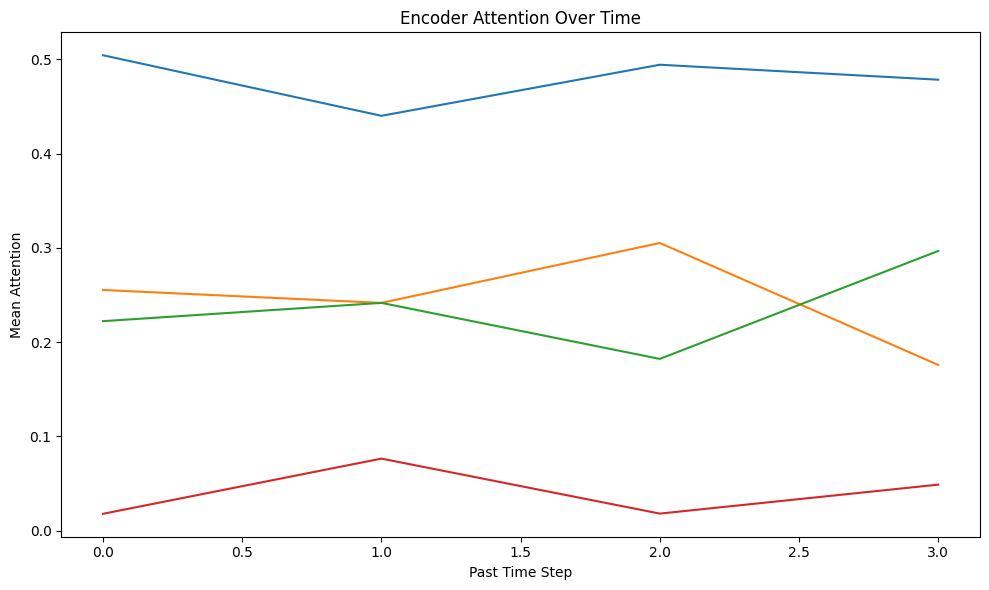

In [92]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(attn_np.shape[0]), attn_np.mean(axis=1))
plt.xlabel("Past Time Step")
plt.ylabel("Mean Attention")
plt.title("Encoder Attention Over Time")
plt.tight_layout()
plt.show()

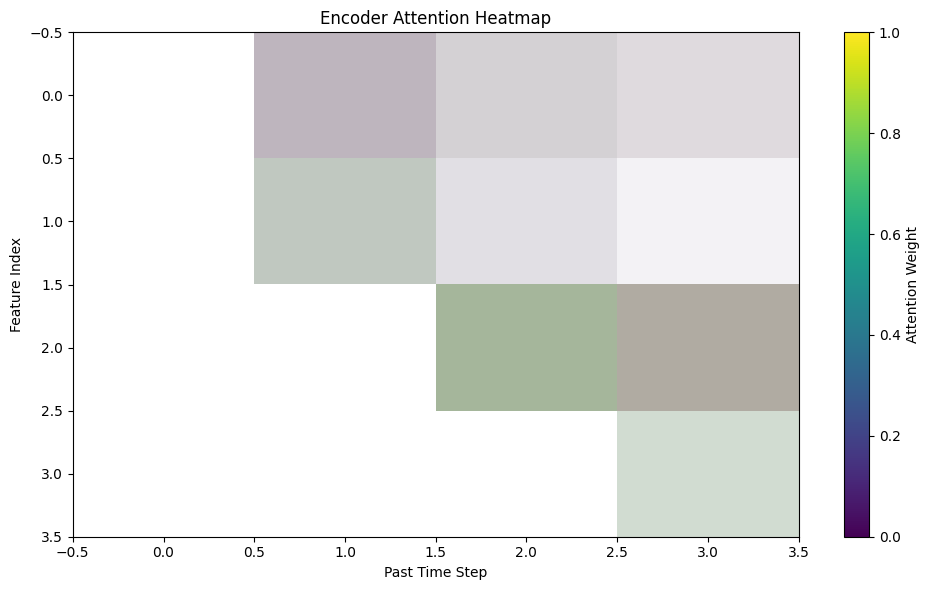

In [93]:
#plot attention heatmap
plt.figure(figsize=(10, 6))
plt.imshow(attn_np.T, aspect="auto", cmap="viridis")
plt.colorbar(label="Attention Weight")
plt.xlabel("Past Time Step")
plt.ylabel("Feature Index")
plt.title("Encoder Attention Heatmap")
plt.tight_layout()
plt.show()

### Historical Feature Importance

In [106]:
hist_vsn_wgts = interp["history_vsn_wgts"]

# average over batch and time
hist_importance = hist_vsn_wgts.mean(dim=(0)).detach().cpu().numpy()

history_feature_names = (
    nf_test.models[0].hist_exog_list + nf_test.models[0].futr_exog_list + [TARGET_COL]
)

print(f"Number of history features: {len(history_feature_names)}")
print(f"Importance shape: {hist_importance.shape}")

Number of history features: 18
Importance shape: (3, 18)


In [112]:
fi_0 = pd.DataFrame(
    {"feature": history_feature_names, "importance": hist_importance[0]}
).sort_values("importance", ascending=False)

print(f"History features and their importance:\n{fi}")

History features and their importance:
         feature  importance
16   day_of_week    0.152084
15   composition    0.115333
6   p0q1_missing    0.115290
7   p0q2_missing    0.071352
1           p0q2    0.062044
10  p2q0_missing    0.051141
4           p2q0    0.050471
2           p0q3    0.045406
13          hour    0.043304
14           way    0.042077
17             y    0.041467
3           p1q0    0.040294
9   p1q0_missing    0.032598
0           p0q1    0.031863
11  p3q0_missing    0.028690
12         month    0.027273
8   p0q3_missing    0.026004
5           p3q0    0.023308


In [113]:
fi_1 = pd.DataFrame(
    {"feature": history_feature_names, "importance": hist_importance[1]}
).sort_values("importance", ascending=False)

print(f"History features and their importance:\n{fi}")

History features and their importance:
         feature  importance
16   day_of_week    0.152084
15   composition    0.115333
6   p0q1_missing    0.115290
7   p0q2_missing    0.071352
1           p0q2    0.062044
10  p2q0_missing    0.051141
4           p2q0    0.050471
2           p0q3    0.045406
13          hour    0.043304
14           way    0.042077
17             y    0.041467
3           p1q0    0.040294
9   p1q0_missing    0.032598
0           p0q1    0.031863
11  p3q0_missing    0.028690
12         month    0.027273
8   p0q3_missing    0.026004
5           p3q0    0.023308


In [114]:
fi_2 = pd.DataFrame(
    {"feature": history_feature_names, "importance": hist_importance[2]}
).sort_values("importance", ascending=False)

print(f"History features and their importance:\n{fi}")

History features and their importance:
         feature  importance
16   day_of_week    0.152084
15   composition    0.115333
6   p0q1_missing    0.115290
7   p0q2_missing    0.071352
1           p0q2    0.062044
10  p2q0_missing    0.051141
4           p2q0    0.050471
2           p0q3    0.045406
13          hour    0.043304
14           way    0.042077
17             y    0.041467
3           p1q0    0.040294
9   p1q0_missing    0.032598
0           p0q1    0.031863
11  p3q0_missing    0.028690
12         month    0.027273
8   p0q3_missing    0.026004
5           p3q0    0.023308


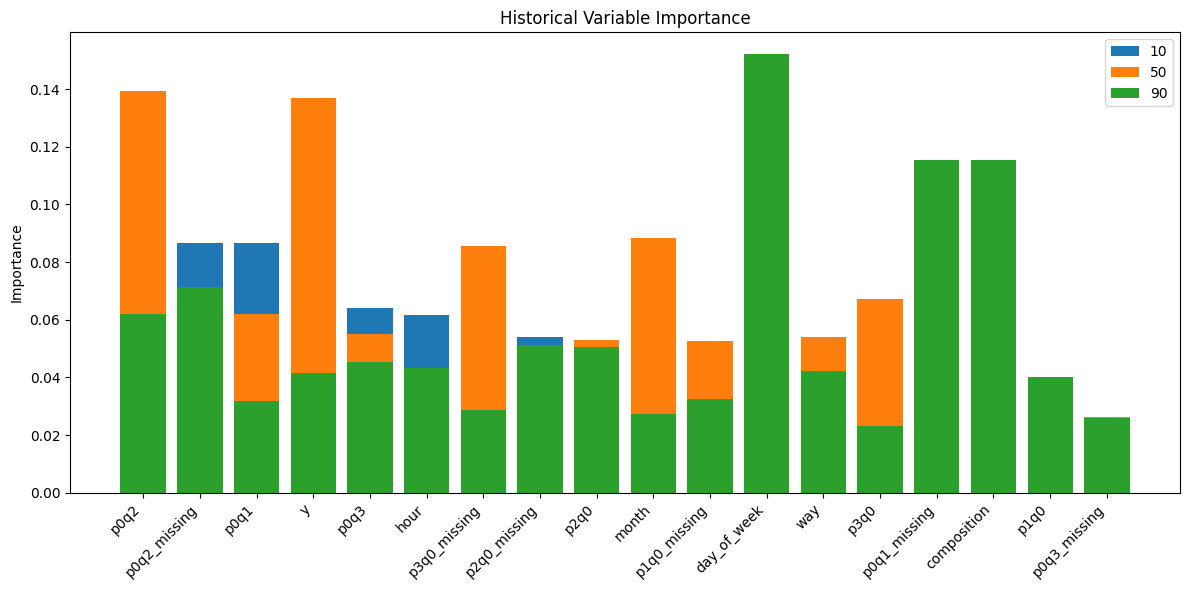

In [117]:
plt.figure(figsize=(12, 6))
plt.bar(fi_0["feature"], fi_0["importance"], label='10')
plt.bar(fi_1["feature"], fi_1["importance"], label='50')
plt.bar(fi_2["feature"], fi_2["importance"], label='90')
plt.xticks(rotation=45, ha="right")
plt.title("Historical Variable Importance")
plt.ylabel("Importance")
plt.legend()
plt.tight_layout()
plt.show()

### Future variable Importance

In [129]:
future_vsn_wgts = interp["future_vsn_wgts"]
future_imp = future_vsn_wgts.mean(dim=(0)).detach().cpu().numpy()
future_imp.shape

(1, 5)

In [130]:
fi_future = pd.DataFrame(
    {"feature": nf_test.models[0].futr_exog_list, "importance": future_imp.squeeze()}
).sort_values("importance", ascending=False)

print(fi_future)

       feature  importance
3  composition    0.354404
1         hour    0.343739
2          way    0.146420
4  day_of_week    0.127321
0        month    0.028116


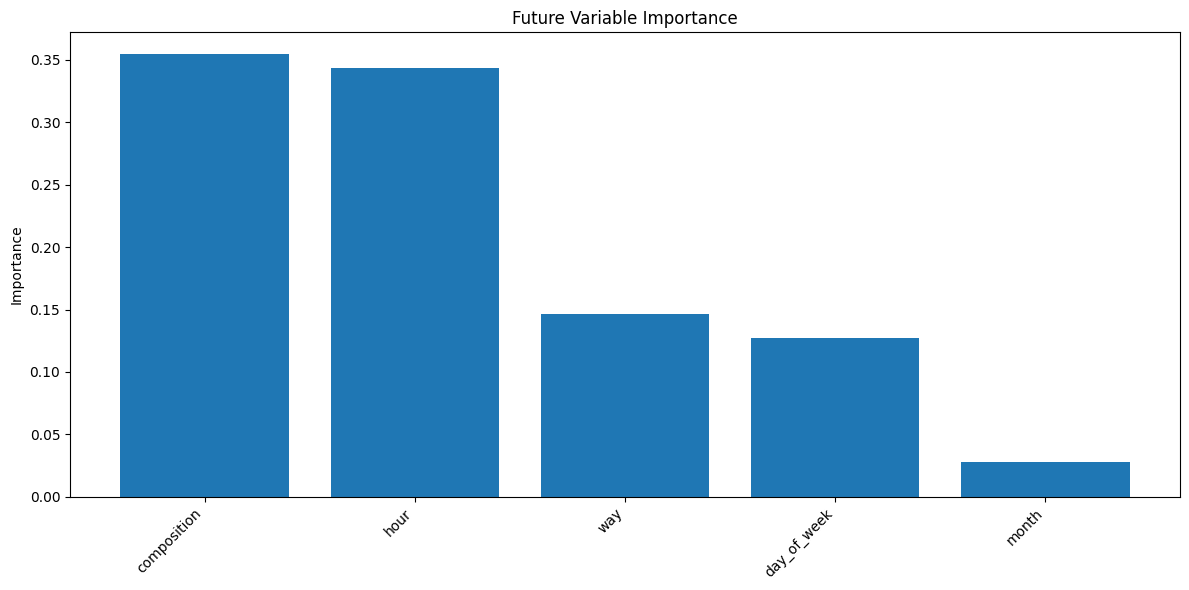

In [132]:
plt.figure(figsize=(12, 6))
plt.bar(fi_future["feature"], fi_future["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Future Variable Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Static sparse weights

In [137]:
static_wgts = interp["static_encoder_sparse_weights"]
static_wgts

[]

Veamos ahora la prediccion para la feature hora:

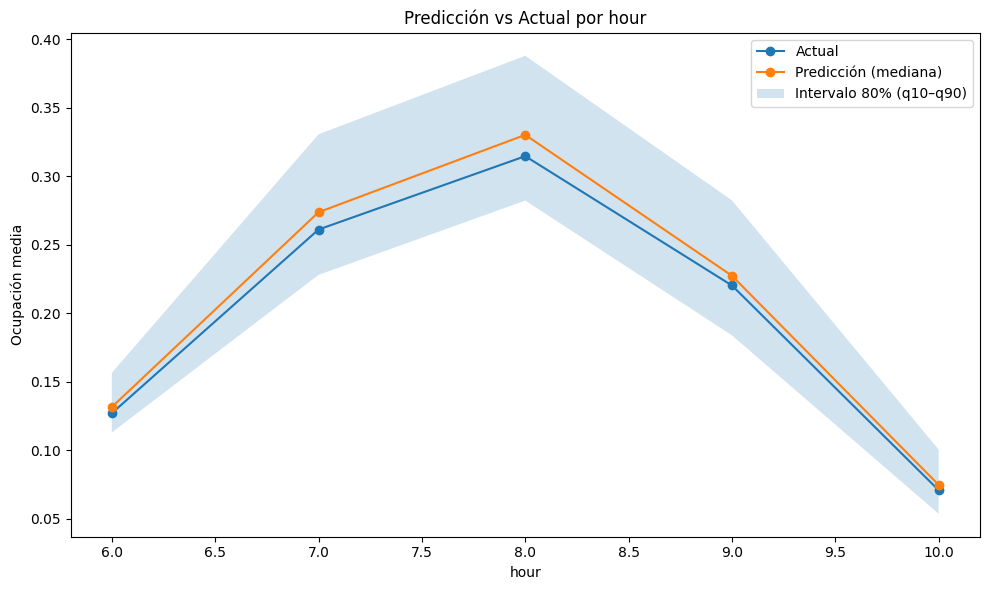

In [140]:
eval_df = test_preds.merge(
    df_test_split[[ID_COL, TIME_COL, TARGET_COL] + futr_cols + hist_cols],
    on=[ID_COL, TIME_COL],
    how="left",
)

pred_col_10 = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]][0]
pred_col_50 = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]][1]
pred_col_90 = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]][2]

# ejemplo con una variable continua/discreta
var = "hour"

cols = [TARGET_COL, pred_col_10, pred_col_50, pred_col_90]
plot_df = eval_df.groupby(var)[cols].mean().reset_index().sort_values(var)

plt.figure(figsize=(10, 6))
plt.plot(plot_df[var], plot_df[TARGET_COL], marker="o", label="Actual")
plt.plot(plot_df[var], plot_df[pred_col_50], marker="o", label="Predicción (mediana)")
plt.fill_between(
    plot_df[var],
    plot_df[pred_col_10],
    plot_df[pred_col_90],
    alpha=0.2,
    label="Intervalo 80% (q10–q90)",
)
plt.xlabel(var)
plt.ylabel("Ocupación media")
plt.title(f"Predicción vs Actual por {var}")
plt.legend()
plt.tight_layout()
plt.show()

Ahora para la feature p0q1

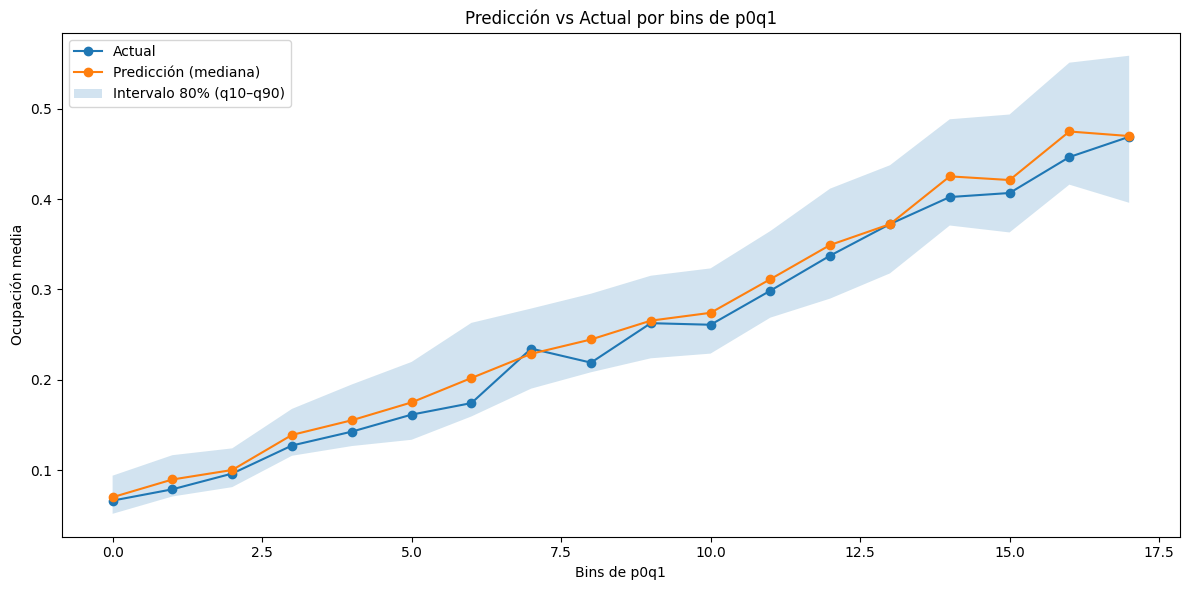

In [141]:
var = "p0q1"
n_bins = 20

eval_df["bin"] = pd.qcut(eval_df[var], q=n_bins, duplicates="drop")

cols = [TARGET_COL, pred_col_10, pred_col_50, pred_col_90]
plot_df = eval_df.groupby("bin", observed=True)[cols].mean().reset_index()
plot_df["bin_center"] = range(len(plot_df))

plt.figure(figsize=(12, 6))
plt.plot(plot_df["bin_center"], plot_df[TARGET_COL], marker="o", label="Actual")
plt.plot(
    plot_df["bin_center"],
    plot_df[pred_col_50],
    marker="o",
    label="Predicción (mediana)",
)
plt.fill_between(
    plot_df["bin_center"],
    plot_df[pred_col_10],
    plot_df[pred_col_90],
    alpha=0.2,
    label="Intervalo 80% (q10–q90)",
)
plt.xlabel(f"Bins de {var}")
plt.ylabel("Ocupación media")
plt.title(f"Predicción vs Actual por bins de {var}")
plt.legend()
plt.tight_layout()
plt.show()

Vamos a ver la prediccion por feature:

In [142]:
def plot_prediction_actual_by_variable(
    eval_df,
    target_col,
    pred_col_50,
    pred_col_10,
    pred_col_90,
    variables,
    n_bins=20,
):
    n_vars = len(variables)
    n_cols = 3
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    pred_cols = [pred_col_10, pred_col_50, pred_col_90]

    for i, var in enumerate(variables):
        ax = axes[i]
        df = eval_df[[var, target_col] + pred_cols].dropna().copy()

        # continua → bins
        if df[var].nunique() > 20:
            df["bin"] = pd.qcut(df[var], q=n_bins, duplicates="drop")
            plot_df = (
                df.groupby("bin", observed=True)[[target_col] + pred_cols]
                .mean()
                .reset_index()
            )
            x = np.arange(len(plot_df))           # fill_between needs array-like, not range()
        else:
            plot_df = (
                df.groupby(var)[[target_col] + pred_cols]
                .mean()
                .reset_index()
                .sort_values(var)
            )
            x = plot_df[var].to_numpy()

        ax.plot(x, plot_df[target_col], marker="o", label="Actual")
        ax.plot(x, plot_df[pred_col_50], marker="o", label="Predicción (mediana)")
        ax.fill_between(
            x, plot_df[pred_col_10], plot_df[pred_col_90],
            alpha=0.2, label="Intervalo 80%",
        )
        ax.set_title(var)
        ax.legend()

    # quitar subplots vacíos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [143]:
eval_df = test_preds.merge(
    df_test_split[[ID_COL, TIME_COL, TARGET_COL] + futr_cols + hist_cols],
    on=[ID_COL, TIME_COL],
    how="left",
)

variables = futr_cols + hist_cols

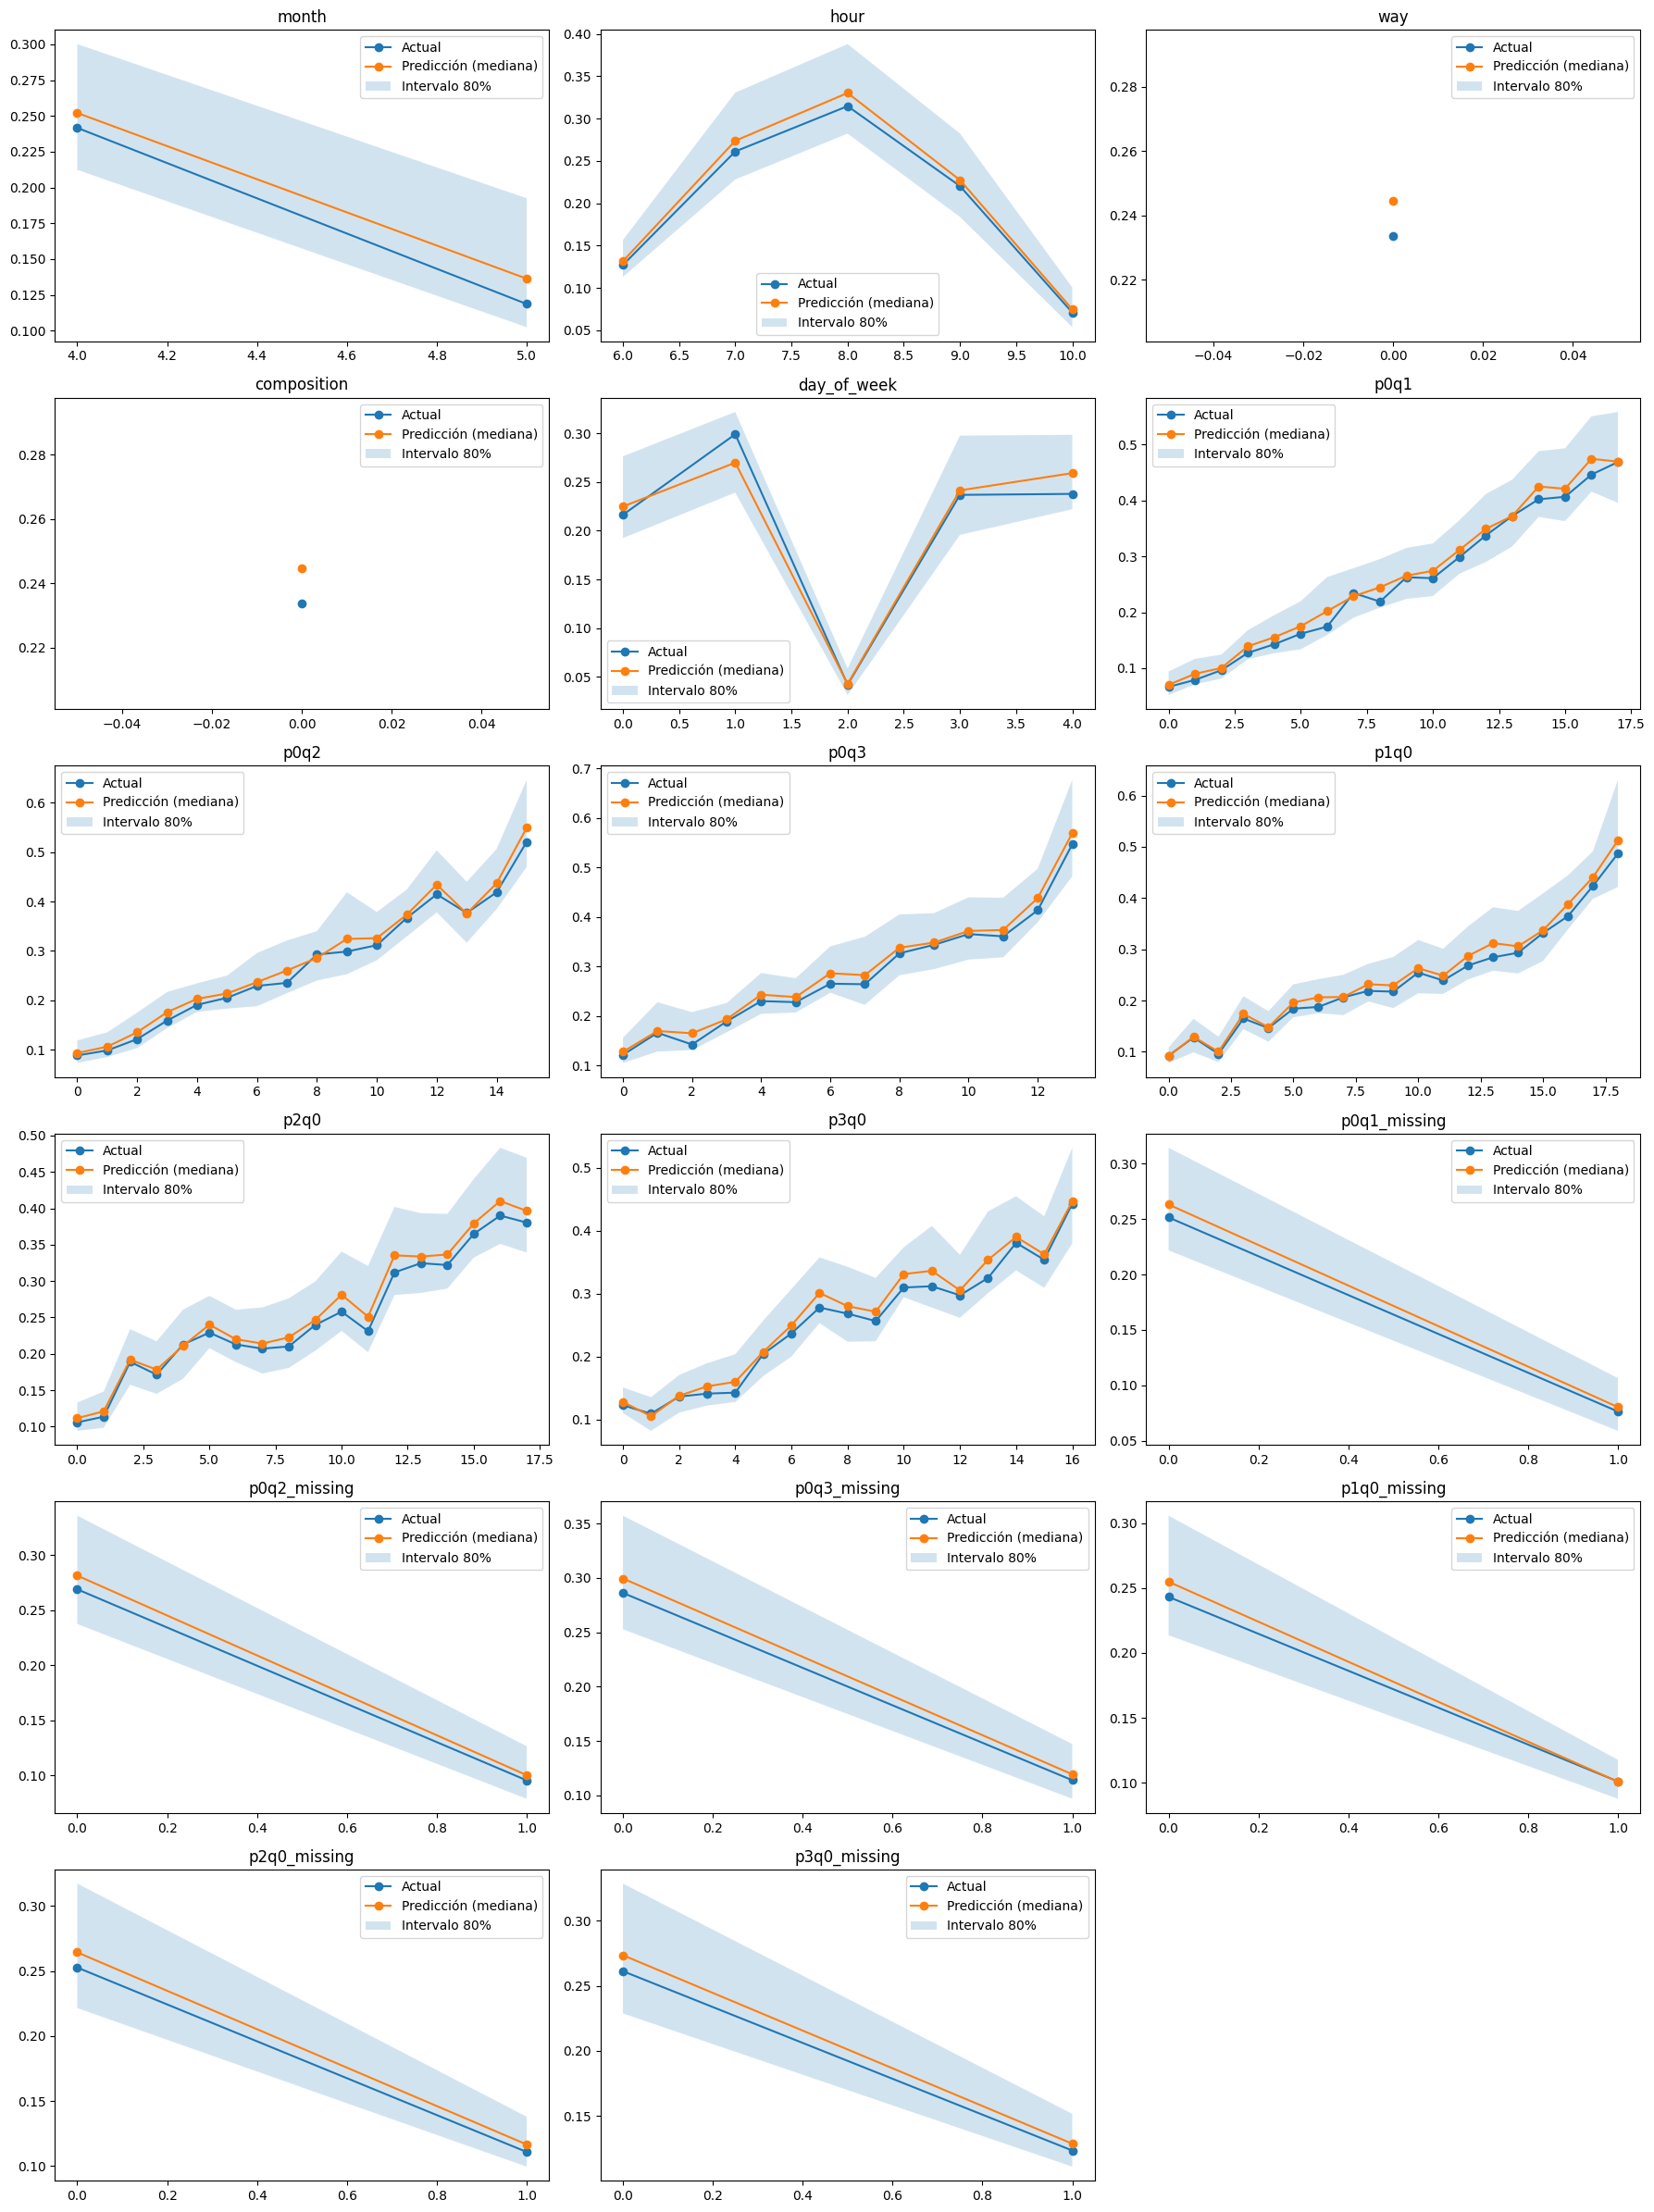

In [144]:
plot_prediction_actual_by_variable(
    eval_df,
    target_col=TARGET_COL,
    pred_col_50=pred_col_50,
    pred_col_10=pred_col_10,
    pred_col_90=pred_col_90,
    variables=variables,
)

Ahora veamos la prediccion por registro

In [145]:
def plot_prediction(
    train_df,
    eval_df,
    id_col,
    time_col,
    target_col,
    pred_col_50,
    pred_col_10,
    pred_col_90,
    unique_id,
    input_size=3,
    title_prefix="Prediction example",
):
    hist = train_df[train_df[id_col] == unique_id].sort_values(time_col).copy()
    future = eval_df[eval_df[id_col] == unique_id].sort_values(time_col).copy()

    if len(hist) == 0 or len(future) == 0:
        print(f"No data for unique_id={unique_id}")
        return

    hist_tail = hist.tail(input_size)

    plt.figure(figsize=(10, 5))

    # pasado
    plt.plot(hist_tail[time_col], hist_tail[target_col], marker="o", label="History")

    # real
    plt.plot(
        future[time_col], future[target_col], marker="o", label="Actual", color="green"
    )

    # predicción: mediana con intervalo 80% (q10–q90) como barras
    yerr = np.vstack(
        [
            future[pred_col_50] - future[pred_col_10],  # distancia hacia abajo (>=0)
            future[pred_col_90] - future[pred_col_50],  # distancia hacia arriba (>=0)
        ]
    )
    plt.errorbar(
        future[time_col],
        future[pred_col_50],
        yerr=yerr,
        marker="o",
        color="red",
        capsize=4,
        label="Predicción (mediana, barras=q10–q90)",
    )

    plt.axvline(hist_tail[time_col].max(), linestyle="--", alpha=0.6)
    plt.title(f"{title_prefix} - {unique_id}")
    plt.xlabel(time_col)
    plt.ylabel(target_col)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [146]:
test_eval = test_preds.merge(
    df_test_split[[ID_COL, TIME_COL, TARGET_COL]], on=[ID_COL, TIME_COL], how="left"
)

# select quantile columns by name
qcols = [c for c in test_preds.columns if c not in [ID_COL, TIME_COL]]
pred_col_50 = [c for c in qcols if c.endswith("-median")][0]
pred_col_10 = [c for c in qcols if "-lo-" in c][0]
pred_col_90 = [c for c in qcols if "-hi-" in c][0]

example_ids = test_eval[ID_COL].drop_duplicates().head(10)

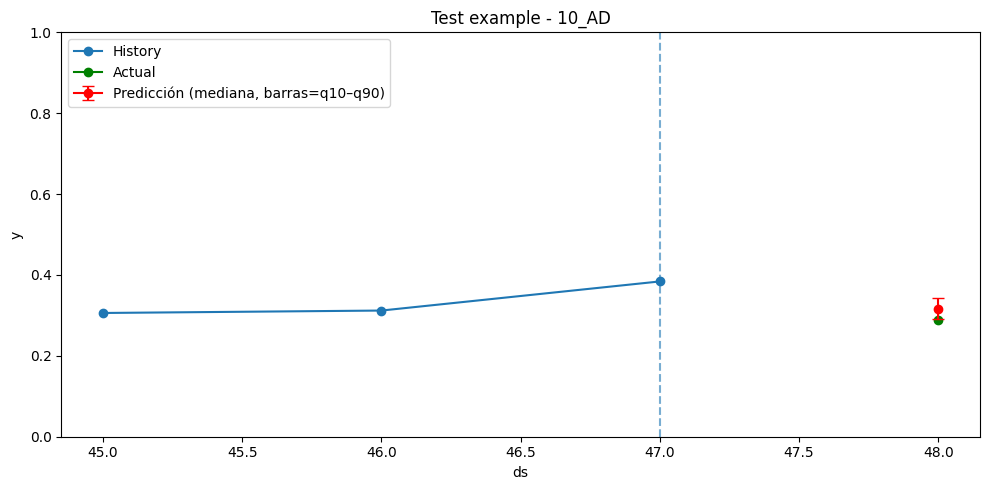

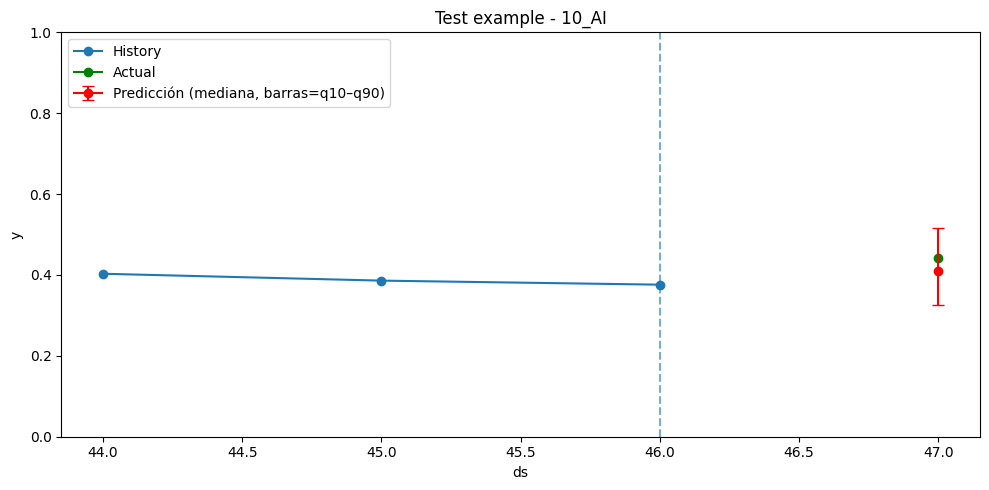

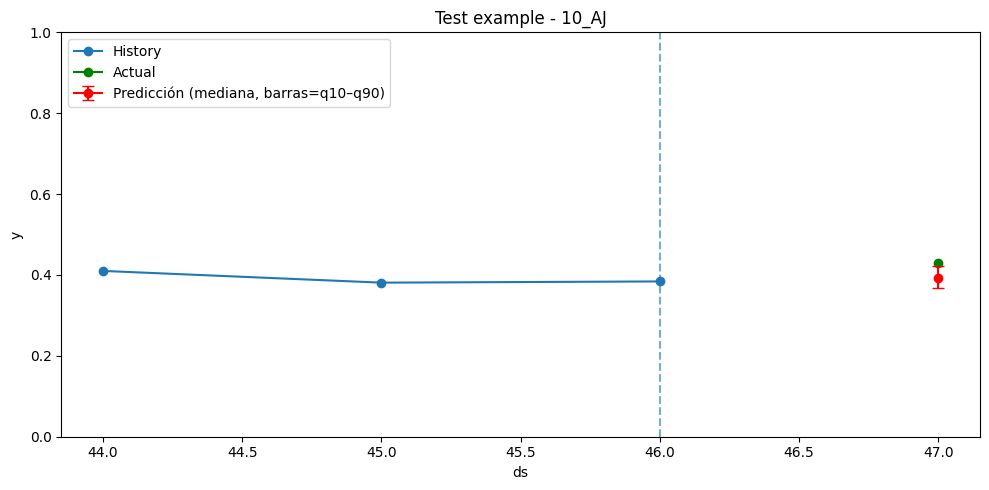

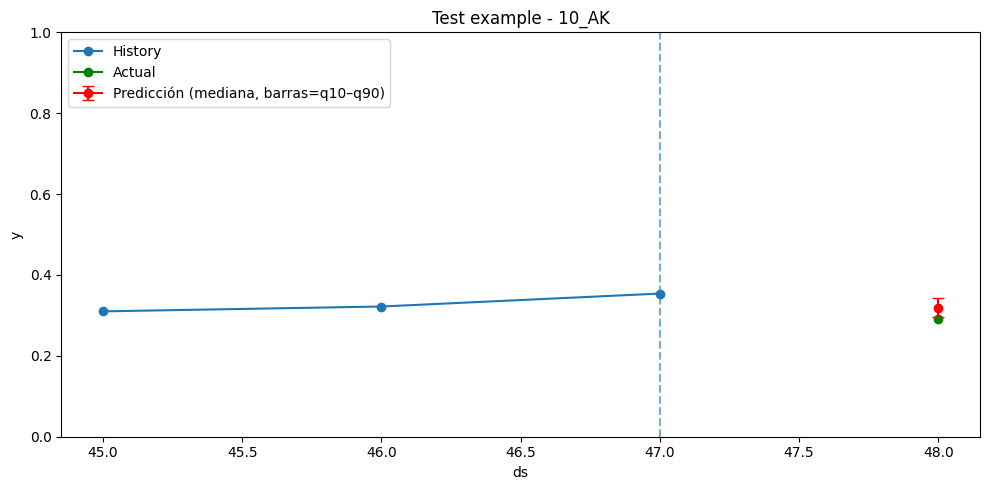

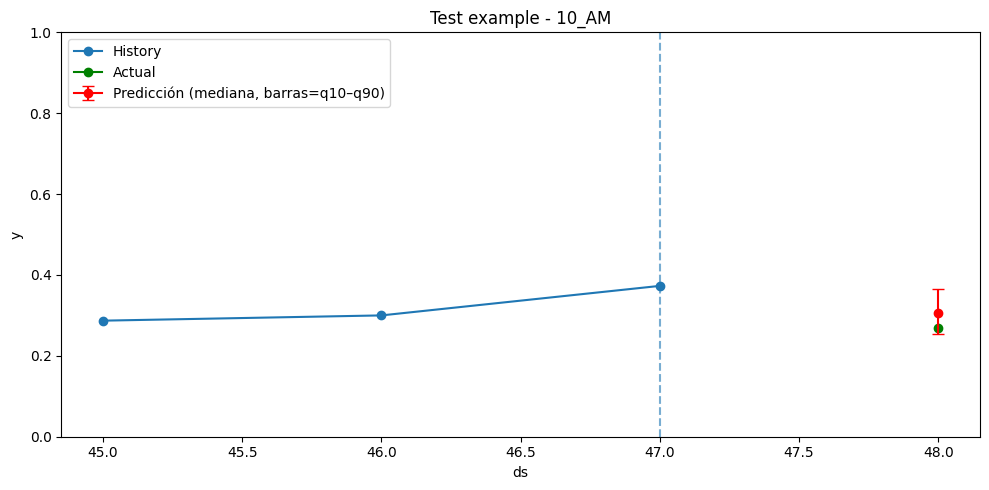

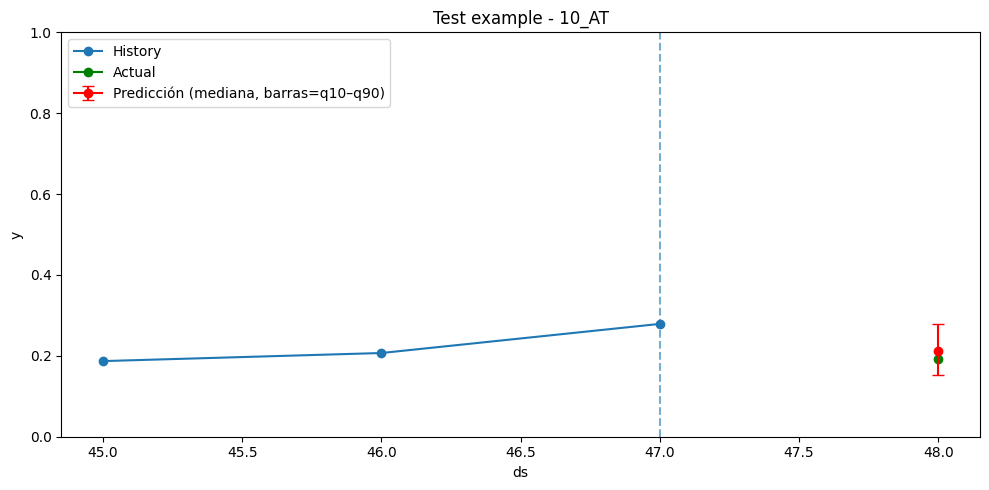

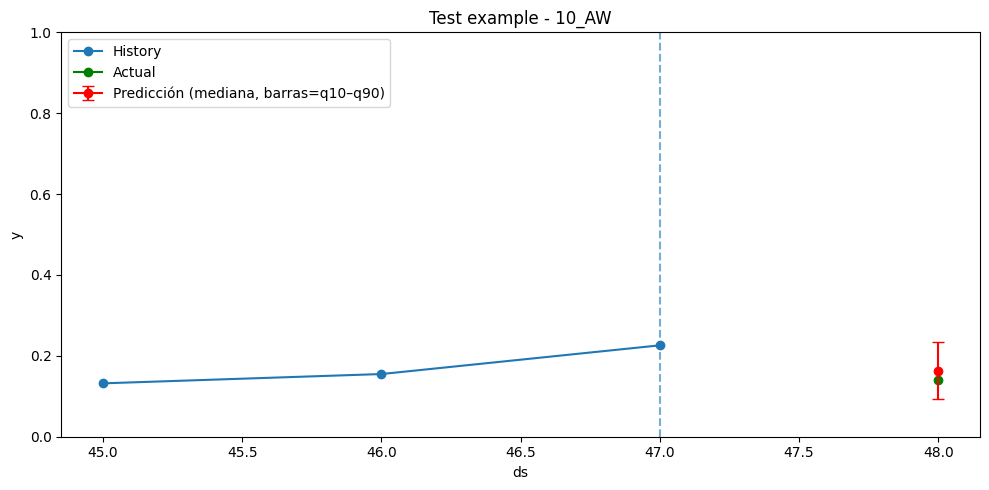

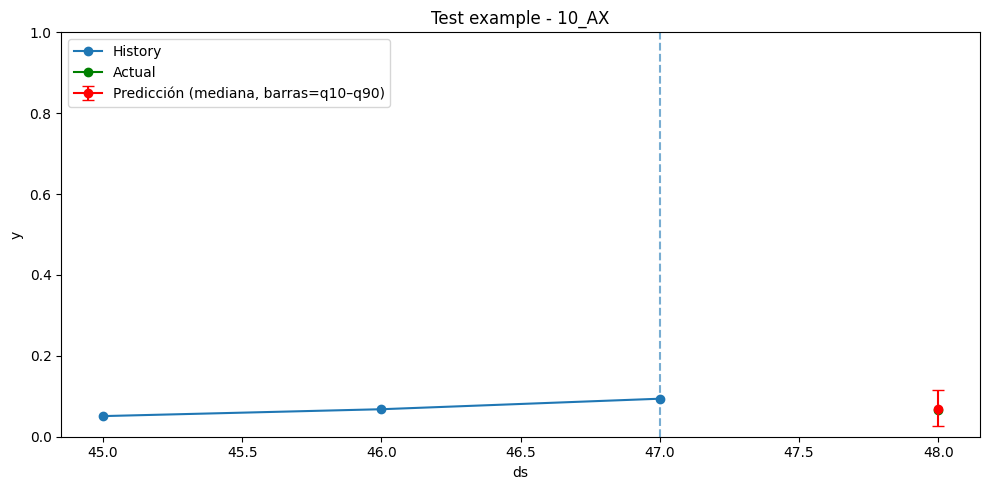

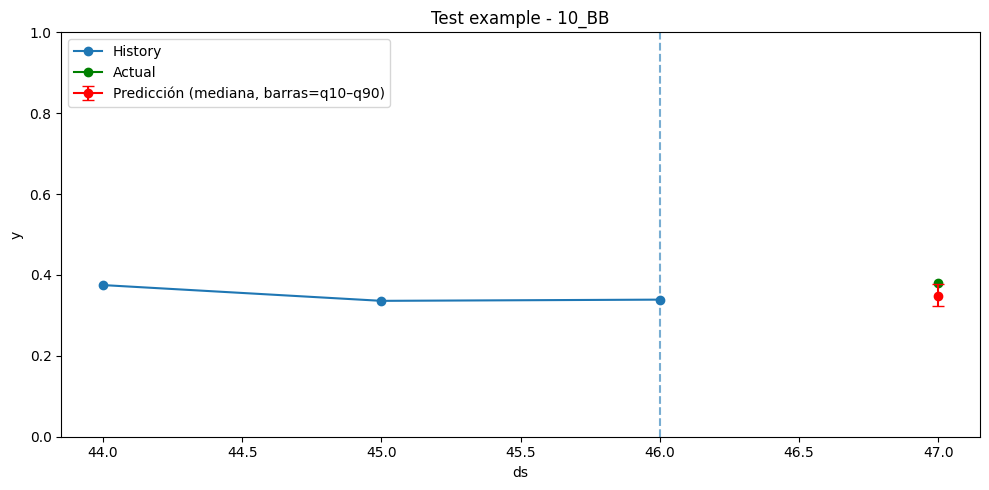

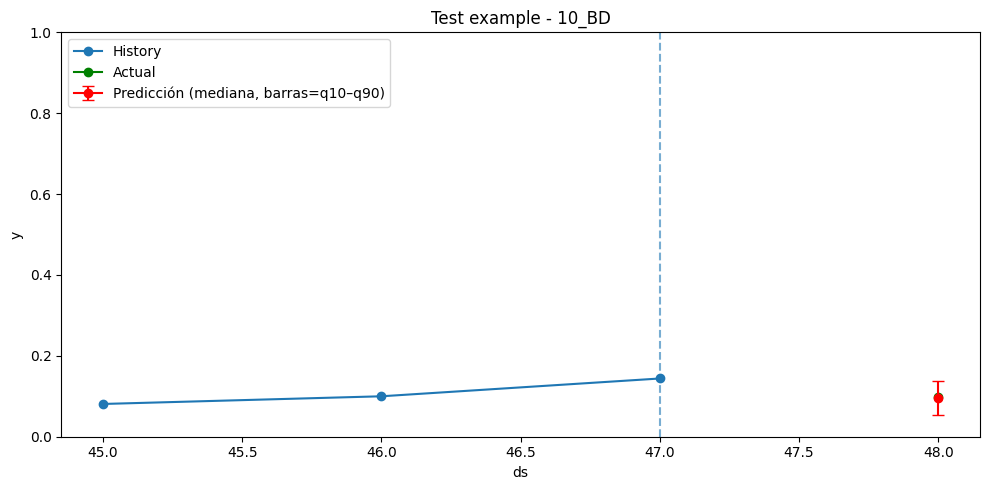

In [147]:
for uid in example_ids:
    plot_prediction(
        train_df=df_train_val,
        eval_df=test_eval,
        id_col=ID_COL,
        time_col=TIME_COL,
        target_col=TARGET_COL,
        pred_col_50=pred_col_50,
        pred_col_10=pred_col_10,
        pred_col_90=pred_col_90,
        unique_id=uid,
        input_size=INPUT_SIZE,
        title_prefix="Test example",
    )

### Un poco de teoria

Fuente: Mastering Modern Time Series Forecasting - A Comprehensive Guide to Statistical, Machine Learning, and Deep Learning Models in Python - Valery Manokhin, PhD

The Temporal Fusion Transformer (TFT) is a hybrid Transformer
architecture designed for interpretable, multi-horizon time series forecasting.
TFT combines recurrent encoders, attention mechanisms, gating layers, and
variable selection modules to integrate static, known future, and observed
historical variables in a unified framework.
Why It’s Included TFT was one of the first Transformer-based forecasting
architectures tailored for practical business forecasting. It offers a rare
balance of accuracy and interpretability and is widely used in domains like
energy, retail, and finance. While newer models like PatchTST outperform it
in raw accuracy, TFT remains a highly relevant choice when explainability
and covariate integration are critical.

Architecture Overview TFT integrates several components into a unified
forecasting pipeline:

1. Variable Selection Networks: Separate gating networks dynamically
select relevant features for each time step and variable type (static,
observed, future).
2. Gated Residual Network (GRN): Nonlinear processing of each input
through a gated residual block with context vectors.
3. Temporal Processing: A recurrent LSTM encoder captures historical
dynamics, and a multi-head attention layer processes the sequence over
time.
4. Static Enrichment + Decoder: Static features modulate attention
and output via conditioning layers, and the decoder produces multi-step
outputs for the target horizon.
TFT outputs both point forecasts and uncertainty estimates, and it offers
interpretability at the variable and time-step level via attention weights and
variable selection scores.

Key Innovations

• Interpretable Variable Selection: Dynamic weighting of input variables helps explain forecasts.

• Multi-Input Support: Integrates static, future, and observed inputs
within a unified architecture.

• Quantile Forecasting: Supports multi-horizon probabilistic outputs
with quantile loss.

Empirical Performance TFT delivers strong results in practical forecasting
scenarios:
• Widely adopted in applied domains requiring interpretability and exogenous input support.

• Performs competitively on medium-range multivariate benchmarks.

• Outperformed by PatchTST and Crossformer in large-scale and long-horizon tasks, but still valuable in enterprise use cases.

![TFT](./Images/tft_comp.png)

Best Use Cases TFT is especially well suited for:

• Applications requiring interpretable and regulated forecasts,

• Business use cases with static metadata, calendar variables, and exoge-
nous drivers,

• Medium-range, multivariate forecasting with known future inputs.

### Ejercicio:

* Realizar predicciones con el modelo entrenado.
* Utilizar la libreria `pytorch forecasting` para entrenar un nuevo modelo. Inspeccionar sus utilidades.

### Referencias:

* Introducing PyTorch Forecasting: https://towardsdatascience.com/introducing-pytorch-forecasting-64de99b9ef46

* Demand forecasting with the Temporal Fusion Transformer: https://pytorch-forecasting.readthedocs.io/en/stable/tutorials/stallion.html#Hyperparameter-tuning

* Building Custom Models: https://pytorch-forecasting.readthedocs.io/en/stable/tutorials/building.html#passing-data

* Link: https://nixtlaverse.nixtla.io/neuralforecast/docs/tutorials/forecasting_tft.html#forecasting-with-tft-temporal-fusion-transformer

![Lenguaje Matemático](./Images/Matematicas.png)

![Contacto](./Images/Contacto.png)